# 09 — Affine-plus-residual graph simulator

This notebook separates collective and local motion. A global head predicts the complete 2D affine displacement increment from the pooled graph state, stiffness mean/standard deviation, and current affine deformation. A one-shot stored-edge attention branch predicts only the non-affine residual; its best-fit affine component is removed before the two outputs are added:

`predicted position = current position + MLP update`

During rollout, predicted positions are fed back autoregressively and geometric edge features are rebuilt from those predictions. It is fit on low-temperature dePablo transitions 0–49 and then rolled out to frame 100 on every trajectory not used for fitting or validation.

In [1]:
import os, sys
from copy import deepcopy
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path/'src/lss').exists())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT/'src'))
from lss.data import load_dataset
from lss.latent.experiment import ground_truth_p_ratio, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.models.affine_residual_edge_simulator import AffineResidualEdgeSimulator
from lss.utils import resolve_device
from scripts.internal_09_transformer_search import (
    acceleration_stats, edge_stats, epoch_pass,
    multi_step_epoch, rollout, target_stats, transition_rows,
)

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Configuration and network split

`MIN_TRAIN_P_RATIO` is applied only when choosing training networks. Validation and test are sampled from the complete unused pool, without any p-ratio restriction, so their rollout metrics measure extrapolation across the full remaining response range. `TRAIN_STEPS = 50` restricts fitting to transitions 0–49; the final rollout continues autoregressively to frame 100.

In [2]:
SEED = 345345
TRAIN_NETWORKS, VAL_NETWORKS = 50, 20
TRAIN_STEPS = 50
ROLLOUT_STEP = 100
WARM_START_FRAMES = 3  # checkpoint-selection baseline
WARM_START_SWEEP = [3, 5, 10, 15, 20]
MIN_TRAIN_P_RATIO = 0
VALIDATION_ROLLOUT_NETWORKS = None  
HIDDEN_SIZE = 64
ONE_STEP_EPOCHS = 1
MULTISTEP_EPOCHS = 20
MULTISTEP_STEPS = 4
MULTISTEP_BATCHES = 10
PATIENCE = 5
TRAIN_BATCHES = 20
LEARNING_RATE = 2e-4
MULTISTEP_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

DATA = ROOT/'data/depablo-near-zero-temp.pt'
OUTPUT = ROOT/'notebooks/results/09_attention_displacement_simulator/depablo_low_temp_affine_residual_history3'
OUTPUT.mkdir(parents=True, exist_ok=True)
CHECKPOINT = OUTPUT/'model_affine_residual_edge.pt'

seed_everything(SEED)
simulations = load_dataset(DATA, edge_multiplicity=1)
METRIC_DATASET = 'depablo_low_temp'
PRATIO_CFG = {}
final_p_ratios = np.asarray([
    ground_truth_p_ratio(sim, dataset_name=METRIC_DATASET, cfg=PRATIO_CFG)
    for sim in simulations
], dtype=float)

order = np.random.default_rng(SEED).permutation(len(simulations))
eligible_mask = np.isfinite(final_p_ratios) & (final_p_ratios > MIN_TRAIN_P_RATIO)
eligible_ids = np.asarray([idx for idx in order if eligible_mask[idx]])
if len(eligible_ids) < TRAIN_NETWORKS:
    raise ValueError(f'Need {TRAIN_NETWORKS} training trajectories with p-ratio > {MIN_TRAIN_P_RATIO}, found {len(eligible_ids)}.')
train_ids = eligible_ids[:TRAIN_NETWORKS]
train_id_set = set(train_ids.tolist())
holdout_ids = np.asarray([idx for idx in order if idx not in train_id_set])
holdout_ids = np.random.default_rng(SEED + 1).permutation(holdout_ids)
if len(holdout_ids) < VAL_NETWORKS:
    raise ValueError(f'Need {VAL_NETWORKS} validation trajectories after training selection, found {len(holdout_ids)}.')
val_ids = holdout_ids[:VAL_NETWORKS]
test_ids = holdout_ids[VAL_NETWORKS:]
train_sims = [simulations[i] for i in train_ids]
val_sims = [simulations[i] for i in val_ids]
test_sims = [simulations[i] for i in test_ids]
print({'dataset': METRIC_DATASET, 'total': len(simulations), 'train': len(train_sims),
       'validation': len(val_sims), 'test': len(test_sims),
       'eligible_above_threshold': len(eligible_ids),
       'validation_at_or_below_threshold': int(np.sum(final_p_ratios[val_ids] <= MIN_TRAIN_P_RATIO)),
       'test_at_or_below_threshold': int(np.sum(final_p_ratios[test_ids] <= MIN_TRAIN_P_RATIO)),
       'nodes': train_sims[0][0].x.size(0), 'frames': len(train_sims[0])})
print(f'train p-ratio range: {final_p_ratios[train_ids].min():.3f} to {final_p_ratios[train_ids].max():.3f}')
print(f'validation p-ratio range: {final_p_ratios[val_ids].min():.3f} to {final_p_ratios[val_ids].max():.3f}')
print(f'test p-ratio range:  {final_p_ratios[test_ids].min():.3f} to {final_p_ratios[test_ids].max():.3f}')

{'dataset': 'depablo_low_temp', 'total': 200, 'train': 50, 'validation': 20, 'test': 130, 'eligible_above_threshold': 82, 'validation_at_or_below_threshold': 14, 'test_at_or_below_threshold': 104, 'nodes': 144, 'frames': 200}
train p-ratio range: 0.003 to 0.409
validation p-ratio range: -0.621 to 0.369
test p-ratio range:  -0.800 to 0.368


## Structured global deformation and local residual

Each node has six inputs: current normalized position, displacement from frame 0, and reference position. One stored-edge attention pass retains stiffness placement, orientation, and connectivity. The global branch receives the pooled node state, mean and standard deviation of static stiffness, and the current best-fit affine deformation. It predicts six affine coefficients: 2D translation plus a 2-by-2 linear deformation. The local decoder predicts node corrections, but a differentiable projection removes their translation, strain, and shear components. Therefore the global branch alone controls collective strain and p-ratio-scale motion, while the edge branch can represent only non-affine rearrangement.

In [3]:
train_rows = transition_rows(train_sims, TRAIN_STEPS)
val_rows = transition_rows(val_sims, TRAIN_STEPS)
target_mean, target_std = target_stats(train_sims, train_rows, 'increment')
accel_mean, accel_std = acceleration_stats(train_sims, train_rows)
edge_mean, edge_std = edge_stats(
    train_sims, train_rows, 'stored', undirected_edges=True,
)
bond_lengths = torch.cat([
    torch.linalg.vector_norm(sim[0].edge_attr[:, :2].float(), dim=1)
    for sim in train_sims
])
length_scale = float(bond_lengths.median().clamp_min(1e-6))
common = {
    'target_mean': target_mean.to(DEVICE), 'target_std': target_std.to(DEVICE),
    'accel_mean': accel_mean.to(DEVICE), 'accel_std': accel_std.to(DEVICE),
    'edge_mean': edge_mean.to(DEVICE), 'edge_std': edge_std.to(DEVICE),
    'length_scale': length_scale, 'distance_floor': None,
    'velocity_skip': False, 'dual_kinematic': False,
    'boundary_features': False, 'boundary_weight': 1.0,
    'node_count_feature': False, 'include_progress': False,
    'include_velocity_feature': True, 'warm_start_frames': WARM_START_FRAMES,
    'static_structure_only': True, 'ignore_box': True,
    'target_mode': 'increment', 'edge_mode': 'stored',
    'undirected_edges': True, 'device': DEVICE,
}
model = AffineResidualEdgeSimulator(
    node_dim=8, edge_dim=13, hidden_size=HIDDEN_SIZE, output_dim=2,
    stiffness_feature_index=8,
).to(DEVICE)
print(f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters')

73,755 trainable parameters


## One-step warm-up and four-step closed-loop training

The first stage uses ordinary teacher forcing so the model learns accurate increments. The second stage starts from the best warm-up checkpoint and differentiates through four recursively predicted frames. At each unrolled step, geometry and global affine state are rebuilt from the model's own prediction. The loss remains node-displacement MSE at every step; p-ratio is used only for validation checkpoint selection. No test trajectory participates in model selection.

In [4]:
def validation_pratio_r2(active_model):
    true_ratio, pred_ratio = [], []
    horizon = min(ROLLOUT_STEP, len(val_sims[0]) - 1)
    selected_val_sims = val_sims if VALIDATION_ROLLOUT_NETWORKS is None else val_sims[:VALIDATION_ROLLOUT_NETWORKS]
    for sim in selected_val_sims:
        predicted = rollout(active_model, sim, horizon, common)
        true_ratio.append(ground_truth_p_ratio(sim[:horizon+1], dataset_name=METRIC_DATASET, cfg=PRATIO_CFG))
        pred_ratio.append(ground_truth_p_ratio(predicted, dataset_name=METRIC_DATASET, cfg=PRATIO_CFG))
    return r2_score(true_ratio, pred_ratio)

seed_everything(SEED)
history_rows = []
best_state, best_rollout_r2 = None, float('-inf')
best_epoch, stale_epochs = 0, 0
global_epoch = 0

def assess_epoch(stage, stage_epoch, unroll_steps, train_loss, train_r2):
    with torch.no_grad():
        val_loss, val_r2 = epoch_pass(
            model, val_sims, val_rows, optimizer=None,
            max_batches=100, seed=SEED, common=common,
        )
        val_pratio_r2 = validation_pratio_r2(model)
    history_rows.append({
        'epoch': global_epoch, 'stage': stage, 'stage_epoch': stage_epoch,
        'unroll_steps': unroll_steps,
        'train_loss': train_loss, 'val_loss': val_loss,
        'train_next_state_r2': train_r2, 'val_next_state_r2': val_r2,
        'val_rollout_pratio_r2': val_pratio_r2,
    })
    print(f"{stage} epoch={stage_epoch:02d} total={global_epoch:02d} "
          f"loss={train_loss:.4g} val_state_R2={val_r2:.3f} "
          f"val_pratio_R2={val_pratio_r2:.3f}", flush=True)
    return val_pratio_r2

# Stage 1: accurate one-step increments from ground-truth states.
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
for stage_epoch in range(1, ONE_STEP_EPOCHS + 1):
    global_epoch += 1
    train_loss, train_r2 = epoch_pass(
        model, train_sims, train_rows, optimizer=optimizer,
        max_batches=TRAIN_BATCHES, seed=SEED + global_epoch, common=common,
    )
    val_pratio_r2 = assess_epoch('one-step warm-up', stage_epoch, 1, train_loss, train_r2)
    if val_pratio_r2 > best_rollout_r2:
        best_rollout_r2 = val_pratio_r2
        best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
        best_epoch, stale_epochs = global_epoch, 0
    else:
        stale_epochs += 1

# Stage 2: start from the best warm-up state and train on predicted states.
model.load_state_dict(best_state)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=MULTISTEP_LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
stale_epochs = 0
for stage_epoch in range(1, MULTISTEP_EPOCHS + 1):
    global_epoch += 1
    train_loss = multi_step_epoch(
        model, train_sims, optimizer=optimizer, transitions=TRAIN_STEPS,
        unroll_steps=MULTISTEP_STEPS, max_batches=MULTISTEP_BATCHES,
        seed=SEED + global_epoch, common=common,
    )
    val_pratio_r2 = assess_epoch(
        'closed-loop refinement', stage_epoch, MULTISTEP_STEPS,
        train_loss, float('nan'),
    )
    if val_pratio_r2 > best_rollout_r2:
        best_rollout_r2 = val_pratio_r2
        best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
        best_epoch, stale_epochs = global_epoch, 0
    else:
        stale_epochs += 1
    if stale_epochs >= PATIENCE:
        print(f'multistep early stopping; best rollout checkpoint was epoch {best_epoch}', flush=True)
        break

model.load_state_dict(best_state)
history = pd.DataFrame(history_rows)
torch.save({
    'model_state': model.state_dict(), 'history': history,
    'target_mean': target_mean.cpu(), 'target_std': target_std.cpu(),
    'accel_mean': accel_mean.cpu(), 'accel_std': accel_std.cpu(),
    'edge_mean': edge_mean.cpu(), 'edge_std': edge_std.cpu(),
    'length_scale': length_scale,
}, CHECKPOINT)
model.eval()
history.to_csv(OUTPUT/'training_history.csv', index=False)
display(history.tail())

one-step warm-up epoch=01 total=01 loss=0.602 val_state_R2=0.504 val_pratio_R2=-1.707
closed-loop refinement epoch=01 total=02 loss=4.1 val_state_R2=0.571 val_pratio_R2=-1.575
closed-loop refinement epoch=02 total=03 loss=3.001 val_state_R2=0.616 val_pratio_R2=-1.667
closed-loop refinement epoch=03 total=04 loss=2.654 val_state_R2=0.656 val_pratio_R2=-1.680
closed-loop refinement epoch=04 total=05 loss=1.917 val_state_R2=0.692 val_pratio_R2=-1.607
closed-loop refinement epoch=05 total=06 loss=1.802 val_state_R2=0.704 val_pratio_R2=-1.719
closed-loop refinement epoch=06 total=07 loss=1.167 val_state_R2=0.722 val_pratio_R2=-1.687
multistep early stopping; best rollout checkpoint was epoch 2


,epoch,stage,stage_epoch,unroll_steps,train_loss,val_loss,train_next_state_r2,val_next_state_r2,val_rollout_pratio_r2
2,3,closed-loop refinement,2,4,3.000677,1.339887,NaN,0.615669,-1.667290
3,4,closed-loop refinement,3,4,2.653876,1.368725,NaN,0.655655,-1.680263
4,5,closed-loop refinement,4,4,1.917427,1.374395,NaN,0.692401,-1.606848
5,6,closed-loop refinement,5,4,1.801906,1.434038,NaN,0.703686,-1.719286
6,7,closed-loop refinement,6,4,1.167477,1.471150,NaN,0.722202,-1.687396


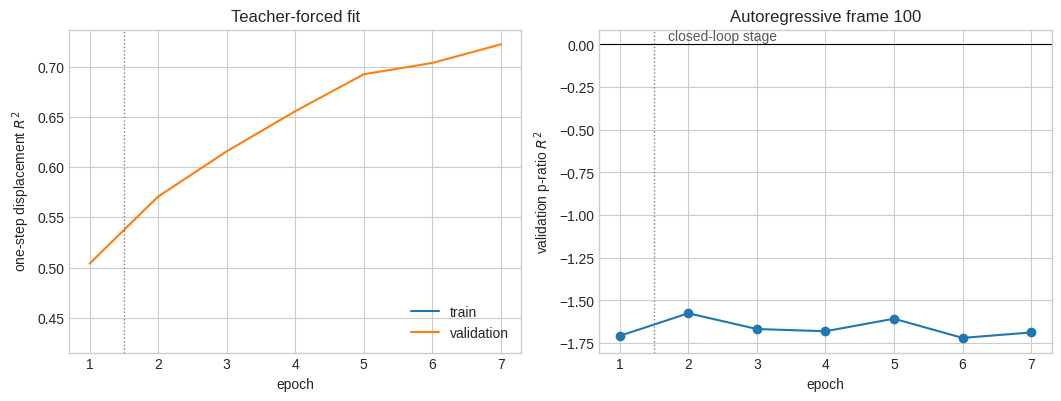

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9), constrained_layout=True)
axes[0].plot(history.epoch, history.train_next_state_r2, label='train')
axes[0].plot(history.epoch, history.val_next_state_r2, label='validation')
axes[0].set(xlabel='epoch', ylabel='one-step displacement $R^2$', title='Teacher-forced fit')
axes[0].legend(frameon=False)
measured = history.dropna(subset=['val_rollout_pratio_r2'])
axes[1].plot(measured.epoch, measured.val_rollout_pratio_r2, 'o-')
axes[1].axhline(0, color='black', lw=.8)
axes[1].set(xlabel='epoch', ylabel='validation p-ratio $R^2$', title=f'Autoregressive frame {ROLLOUT_STEP}')
for ax in axes:
    ax.axvline(ONE_STEP_EPOCHS + 0.5, color='0.5', ls=':', lw=1)
axes[1].text(ONE_STEP_EPOCHS + 0.7, axes[1].get_ylim()[1], 'closed-loop stage', va='top', color='0.35')
fig.savefig(OUTPUT/'training_diagnostics.png', dpi=250, bbox_inches='tight')

## Final untouched-network rollout

Each unused trajectory is initialized only with its static frame and recursively predicted through frame 100. The final scatter tests whether the simulator preserves network-specific p-ratio outside the filtered training set.

In [6]:
selected_test = test_sims
rows = []
for test_index, sim in enumerate(selected_test):
    predicted = rollout(model, sim, ROLLOUT_STEP, common)
    rows.append({
        'test_index': test_index,
        'source_index': int(test_ids[test_index]),
        'training_filter_passed': bool(final_p_ratios[test_ids[test_index]] > MIN_TRAIN_P_RATIO),
        'rollout_step': ROLLOUT_STEP,
        'true_p_ratio': ground_truth_p_ratio(sim[:ROLLOUT_STEP+1], dataset_name=METRIC_DATASET, cfg=PRATIO_CFG),
        'pred_p_ratio': ground_truth_p_ratio(predicted[:ROLLOUT_STEP+1], dataset_name=METRIC_DATASET, cfg=PRATIO_CFG),
    })
    if test_index == 0 or (test_index+1) % 10 == 0:
        print(f'rollout {test_index+1}/{len(selected_test)}', flush=True)

predictions = pd.DataFrame(rows).dropna(subset=['true_p_ratio','pred_p_ratio'])
rollout_metrics = pd.DataFrame([{
    'rollout_step': ROLLOUT_STEP, 'test_networks': len(predictions),
    'p_ratio_r2': r2_score(predictions.true_p_ratio, predictions.pred_p_ratio),
    'p_ratio_pearson': pearson_r(predictions.true_p_ratio, predictions.pred_p_ratio),
    'p_ratio_mse': float(np.mean(np.square(predictions.pred_p_ratio-predictions.true_p_ratio))),
}])
predictions.to_csv(OUTPUT/'test_predictions.csv', index=False)
rollout_metrics.to_csv(OUTPUT/'test_metrics.csv', index=False)
display(rollout_metrics.round(5))

rollout 1/130
rollout 10/130
rollout 20/130
rollout 30/130
rollout 40/130
rollout 50/130
rollout 60/130
rollout 70/130
rollout 80/130
rollout 90/130
rollout 100/130
rollout 110/130
rollout 120/130
rollout 130/130


,rollout_step,test_networks,p_ratio_r2,p_ratio_pearson,p_ratio_mse
0,100,130,-2.18794,0.90513,0.23165


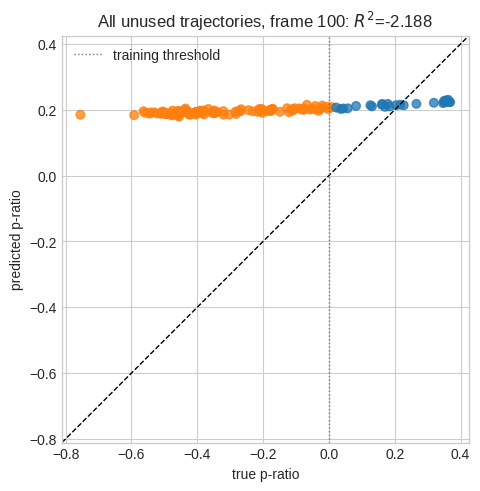

In [7]:
group = predictions
step_r2 = rollout_metrics.p_ratio_r2.iloc[0]
lo = min(group.true_p_ratio.min(), group.pred_p_ratio.min())
hi = max(group.true_p_ratio.max(), group.pred_p_ratio.max())
pad = .05 * max(hi-lo, 1e-6); limits = [lo-pad, hi+pad]
fig, ax = plt.subplots(figsize=(5.2, 4.8), constrained_layout=True)
colors = np.where(group.training_filter_passed, 'tab:blue', 'tab:orange')
ax.scatter(group.true_p_ratio, group.pred_p_ratio, c=colors, s=38, alpha=.75)
ax.plot(limits, limits, '--', color='black', lw=1)
ax.axvline(MIN_TRAIN_P_RATIO, color='0.45', ls=':', lw=1, label='training threshold')
ax.set(xlim=limits, ylim=limits, xlabel='true p-ratio', ylabel='predicted p-ratio',
       title=f'All unused trajectories, frame {ROLLOUT_STEP}: $R^2$={step_r2:.3f}')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)
fig.savefig(OUTPUT/'pratio_scatter_frame_100.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT/'pratio_scatter_frame_100.pdf', bbox_inches='tight')

## Observed-history baseline sweep

Evaluate the same trained simulator with increasingly long true prefixes. This isolates whether poor OOD amplitude is caused by an insufficiently long dynamical observation. No model is retrained or selected on the test set in this diagnostic.

warm start 3: 1/130 rollouts
warm start 3: 25/130 rollouts
warm start 3: 50/130 rollouts
warm start 3: 75/130 rollouts
warm start 3: 100/130 rollouts
warm start 3: 125/130 rollouts
warm start 3: 130/130 rollouts
warm start 5: 1/130 rollouts
warm start 5: 25/130 rollouts
warm start 5: 50/130 rollouts
warm start 5: 75/130 rollouts
warm start 5: 100/130 rollouts
warm start 5: 125/130 rollouts
warm start 5: 130/130 rollouts
warm start 10: 1/130 rollouts
warm start 10: 25/130 rollouts
warm start 10: 50/130 rollouts
warm start 10: 75/130 rollouts
warm start 10: 100/130 rollouts
warm start 10: 125/130 rollouts
warm start 10: 130/130 rollouts
warm start 15: 1/130 rollouts
warm start 15: 25/130 rollouts
warm start 15: 50/130 rollouts
warm start 15: 75/130 rollouts
warm start 15: 100/130 rollouts
warm start 15: 125/130 rollouts
warm start 15: 130/130 rollouts
warm start 20: 1/130 rollouts
warm start 20: 25/130 rollouts
warm start 20: 50/130 rollouts
warm start 20: 75/130 rollouts
warm start 20: 

,warm_start_frame,test_networks,p_ratio_r2,p_ratio_pearson,true_std,pred_std,pred_to_true_std,true_mean,pred_mean
0,3,130,-2.1879,0.9051,0.2696,0.0112,0.0415,-0.2058,0.1995
1,5,130,-1.9641,0.9734,0.2696,0.0201,0.0744,-0.2058,0.1851
2,10,130,-1.4472,0.9946,0.2696,0.0428,0.1588,-0.2058,0.1495
3,15,130,-1.0071,0.9975,0.2696,0.0643,0.2387,-0.2058,0.1161
4,20,130,-0.6388,0.9985,0.2696,0.0843,0.3127,-0.2058,0.0852


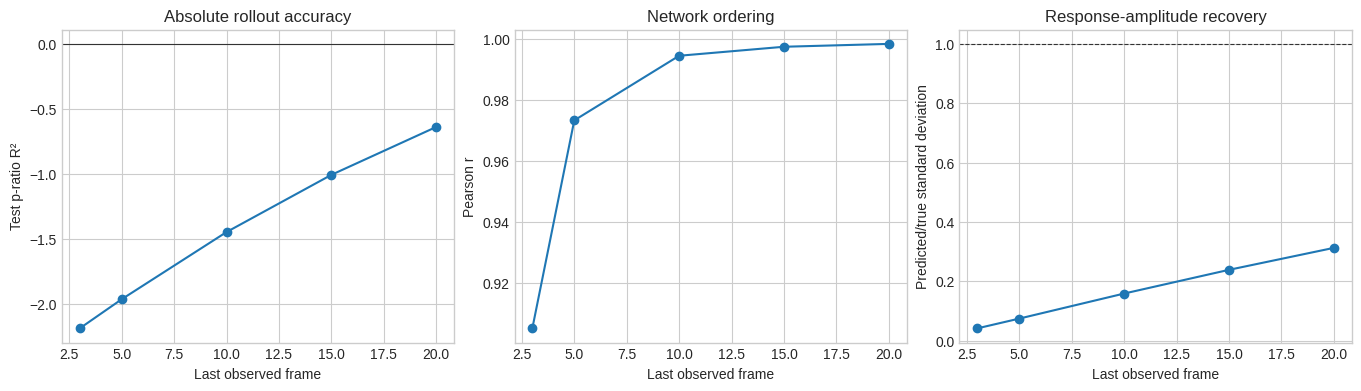

In [8]:
warm_rows = []
horizon = min(ROLLOUT_STEP, min(len(sim)-1 for sim in test_sims))
for warm_start in WARM_START_SWEEP:
    true_values, predicted_values = [], []
    warm_common = {**common, 'warm_start_frames': int(warm_start)}
    for sim_index, sim in enumerate(test_sims):
        predicted_path = rollout(model, sim, horizon, warm_common)
        true_values.append(ground_truth_p_ratio(sim[:horizon+1], dataset_name=METRIC_DATASET, cfg=PRATIO_CFG))
        predicted_values.append(ground_truth_p_ratio(predicted_path, dataset_name=METRIC_DATASET, cfg=PRATIO_CFG))
        if sim_index == 0 or (sim_index + 1) % 25 == 0 or sim_index + 1 == len(test_sims):
            print(f'warm start {warm_start}: {sim_index+1}/{len(test_sims)} rollouts', flush=True)
    true_values = np.asarray(true_values, float); predicted_values = np.asarray(predicted_values, float)
    valid = np.isfinite(true_values) & np.isfinite(predicted_values)
    true_values, predicted_values = true_values[valid], predicted_values[valid]
    warm_rows.append({
        'warm_start_frame': int(warm_start), 'test_networks': len(true_values),
        'p_ratio_r2': r2_score(true_values, predicted_values),
        'p_ratio_pearson': pearson_r(true_values, predicted_values),
        'true_std': float(true_values.std()), 'pred_std': float(predicted_values.std()),
        'pred_to_true_std': float(predicted_values.std()/max(true_values.std(), 1e-12)),
        'true_mean': float(true_values.mean()), 'pred_mean': float(predicted_values.mean()),
    })
warm_start_results = pd.DataFrame(warm_rows)
warm_start_results.to_csv(OUTPUT/'warm_start_sweep.csv', index=False)
display(warm_start_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
axes[0].plot(warm_start_results.warm_start_frame, warm_start_results.p_ratio_r2, marker='o')
axes[0].axhline(0, color='0.2', lw=.8)
axes[0].set(xlabel='Last observed frame', ylabel='Test p-ratio R²', title='Absolute rollout accuracy')
axes[1].plot(warm_start_results.warm_start_frame, warm_start_results.p_ratio_pearson, marker='o')
axes[1].set(xlabel='Last observed frame', ylabel='Pearson r', title='Network ordering')
axes[2].plot(warm_start_results.warm_start_frame, warm_start_results.pred_to_true_std, marker='o')
axes[2].axhline(1, color='0.2', ls='--', lw=.8)
axes[2].set(xlabel='Last observed frame', ylabel='Predicted/true standard deviation', title='Response-amplitude recovery')
fig.savefig(OUTPUT/'warm_start_sweep.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT/'warm_start_sweep.pdf', bbox_inches='tight')
plt.show()